In [51]:
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, classification_report
#from sklearn.tree import DecisionTreeClassifier
#from sklearn.naive_bayes import GaussianNB, MultinomialNB
#from sklearn.base import BaseEstimator, TransformerMixin
#from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
#from sklearn.metrics import classification_report, cohen_kappa_score, accuracy_score
#from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
#from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer,\
KBinsDiscretizer, OneHotEncoder, QuantileTransformer

In [2]:
from sklearn.datasets import load_iris
iris = load_iris()

In [4]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

In [7]:
df['flower_name'] = df.target.apply(lambda x: iris.target_names[x])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [20]:
setosa = df[:50]
versicolor = df[50:100]
virginica = df[100:]

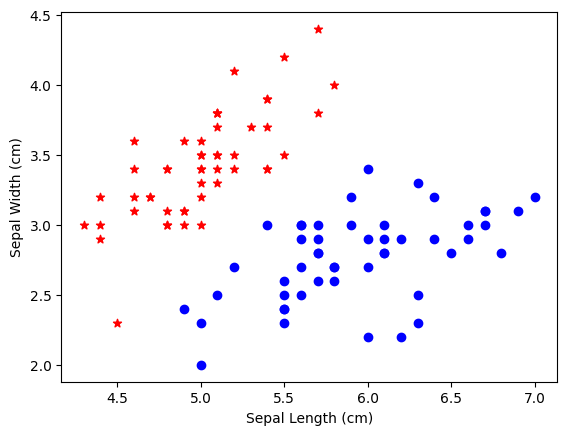

In [23]:
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.scatter(setosa['sepal length (cm)'], setosa['sepal width (cm)'],color="red", marker='*')
plt.scatter(versicolor['sepal length (cm)'], versicolor['sepal width (cm)'],color="blue", marker='o')
plt.show()

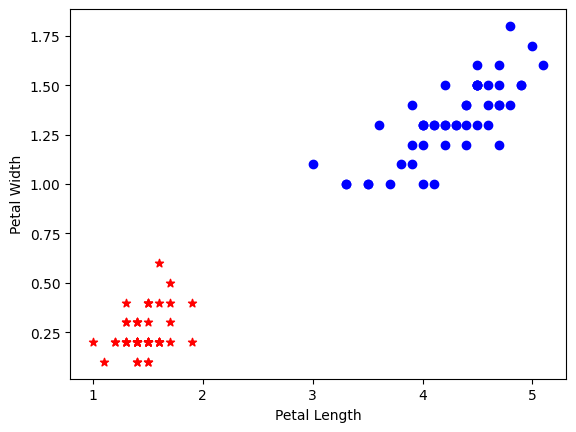

In [24]:
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.scatter(setosa['petal length (cm)'], setosa['petal width (cm)'], color="red", marker='*')
plt.scatter(versicolor['petal length (cm)'], versicolor['petal width (cm)'], color="blue", marker='o')
plt.show()

#### Training and Testing

In [42]:
X = df.drop(columns=['target', 'flower_name'], axis='columns')
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 12)

In [43]:
X_test

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
40,5.0,3.5,1.3,0.3
146,6.3,2.5,5.0,1.9
38,4.4,3.0,1.3,0.2
99,5.7,2.8,4.1,1.3
143,6.8,3.2,5.9,2.3
116,6.5,3.0,5.5,1.8
148,6.2,3.4,5.4,2.3
39,5.1,3.4,1.5,0.2
135,7.7,3.0,6.1,2.3
23,5.1,3.3,1.7,0.5


In [44]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)
score = knn.score(X_test, y_test)
pred = knn.predict(X_test)

In [46]:
print(f'Score of KNN Classifier: {score:.4f}')
print(pred)

Score of KNN Classifier: 0.9667
[0 2 0 1 2 2 2 0 2 0 1 0 0 0 1 2 2 1 0 1 0 1 1 1 0 2 1 1 0 0]


#### Using the model

In [47]:
knn.predict([[4.8,3.0,1.5,0.3]])

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([0])

In [48]:
cm = confusion_matrix(pred, y_test)
cm

array([[12,  0,  0],
       [ 0,  9,  1],
       [ 0,  0,  8]])

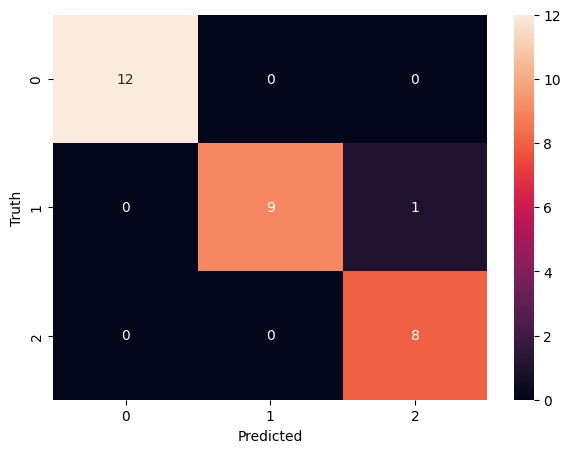

In [50]:
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [53]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.90      1.00      0.95         9
           2       1.00      0.89      0.94         9

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30

